In [76]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [77]:
case_name = "MPHYS AT10"
#User choice:
solveConduction = True
plot_at_z1 = []

########## Thermal hydraulics parameters ##########
## Geometric parameters
#User choice:
solveConduction = True
zPlotting = []

If = 8
I1 = 3
# Sensitivity to the meshing parameters
Iz1 = 75 # number of control volumes in the axial direction, added 70 for comparison with GeN-Foam
# Iz1 = 10, 20, 40, 50, 70, 80 and 160 are supported for the DONJON solution


########## Choice of Thermalhydraulics correlation ##########
voidFractionCorrel = 'EPRIvoidCorrel' # 'modBestion', 'HEM1', 'GEramp', 'EPRIvoidModel'
frfaccorel = "Churchill" # 'base', 'blasius', 'Churchill', 'Churchill_notOK' ?
P2Pcorel = "lockhartMartinelli" # 'base', 'HEM1', 'HEM2', 'MNmodel', "lockhartMartinelli"
numericalMethod = "FVM" # "FVM": Solves the system using matrix inversion with preconditioning.
                        # "GaussSiedel" : Applies the Gauss-Seidel iterative solver.
                        # "BiCG" : Uses the BiConjugate Gradient method for solving non-symmetric or indefinite matrices.
                        # "BiCGStab" : Applies the BiCGStab (BiConjugate Gradient Stabilized) method to ensure faster and more stable convergence.

########## Thermal hydraulics parameters ##########
## Geometric parameters
canalType = "square" # "square", "cylindrical"
pitch =1.295e-2 #1.295e-2 # m : ATRIUM10 pincell pitch   0.0126 #
fuelRadius = 0.4435e-2 # m : fuel rod radius
#gapRadius = fuelRadius + 0.000001 # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
gapRadius = 0.4520e-2 # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
cladRadius = 0.5140e-2 # m : clad external radius
height = 1.655 # m : height : 3.8 m : active core height in BWRX-300 SMR, 1.555 m : for GeNFoam comparison.


## Fluid parameters
# T_inlet, T_outlet = 270, 287 Celcius
#tInlet = 270 + 273.15 # K, for BWRX-300 SMR core, try lowering the inlet temperature to set boiling point back and reduce the void fraction increase in the first few cm
tInlet = 270 + 273.15 # K, for BWRX-300 SMR core
#Nominal operating pressure = 7.2 MPa (abs)
pOutlet =  7.2e6 # Pa 
# Nominal coolant flow rate = 1530 kg/s
massFlowRate = 8.407 * 10**(-2) #1530  / (200*91)  # kg/s

## Material parameters
kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
Hgap = 10000 
#Hgap = 9000
kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
# k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity

############ Nuclear Parameters ###########
# Number of fuel rods and assemblies for a small modular Boiling Water Reactor core
qFiss_init_1 = [0, 0, 0, 0, 0,2.564562941138757765e+08,
4.606563359818137884e+08,
6.385889898192162514e+08,
7.966173287146114111e+08,
9.346876843658176661e+08,
1.049026957254834294e+09,
1.130789081613284111e+09,
1.150140973202926397e+09,
1.108569337369034767e+09,
1.055785428336030245e+09,
1.004279242858528256e+09,
9.543893314359576702e+08,
9.089756320934396982e+08,
8.667470820122994184e+08,
8.280351174182662964e+08,
7.905057229690717459e+08,
7.554755728686988354e+08,
7.224685888143644333e+08,
6.911920184435430765e+08,
6.614450169170019627e+08,
6.331069528314148188e+08,
6.061197559277513027e+08,
5.807321145358361006e+08,
5.561661272914043665e+08,
5.326631014653288722e+08,
5.097330414569107294e+08,
4.877118743771567941e+08,
4.666589154829862714e+08,
4.464917281279732585e+08,
4.271445942088661790e+08,
4.085647347076887488e+08,
3.907097752317554355e+08,
3.735427215578536391e+08,
3.570304700811994076e+08,
3.411426295138564706e+08,
3.258510095463058352e+08,
3.111291984374625087e+08,
2.969528075678178072e+08,
2.832995603678619266e+08,
2.701503149949405193e+08,
2.574903982595574856e+08,
2.453126514238079488e+08,
2.337728548494936228e+08,
2.224196967991268337e+08,
2.114198958303166032e+08,
2.007686275762138665e+08,
1.904553762510111630e+08,
1.804682587944314182e+08,
1.707903676903969944e+08,
1.614050622080946565e+08,
1.522962574193436801e+08,
1.434483241541218162e+08,
1.348461223487246335e+08,
1.264747120283900201e+08,
1.183196645567856878e+08,
1.103668958952060193e+08,
1.026025887902103215e+08,
9.501365964783260226e+07,
8.758616338002669811e+07,
8.030739989664377272e+07,
7.316446901858410239e+07,
6.614427047780513018e+07,
5.923332050244478136e+07,
5.241720713024570048e+07,
4.567945637118443847e+07,
3.899987591562700272e+07,
3.235112583208712190e+07,
2.569273257287562639e+07,
1.896002294369014725e+07,
1.204371086243382096e+07,
]

qFiss_init_2 = [0,0,0,0,0,6.636480184627691656e+07,
1.203607274475849271e+08,
1.690703808642655015e+08,
2.146628930296683908e+08,
2.577359073983282149e+08,
2.982980722592046261e+08,
3.361638606936126947e+08,
3.710920765912090540e+08,
4.028398786658587456e+08,
4.311784763219730854e+08,
4.558899504634524584e+08,
4.767562930657761097e+08,
4.935055610169775486e+08,
5.056673674332319498e+08,
5.122225481436123848e+08,
5.106402892097806931e+08,
4.903793712988448739e+08,
4.675438422021413445e+08,
4.447928840339780450e+08,
4.225981731402893662e+08,
4.012143115909135342e+08,
3.809644208042048812e+08,
3.618054594243107438e+08,
3.436913625290604830e+08,
3.265364920488602519e+08,
3.100894251049303412e+08,
2.945607219665191770e+08,
2.798697912519288659e+08,
2.660304835627623498e+08,
2.527302599627852142e+08,
2.400498674584244490e+08,
2.279685857275490165e+08,
2.164604921353839338e+08,
2.054992638692601919e+08,
1.950610236480921209e+08,
1.851266296292180121e+08,
1.756848545994669199e+08,
1.667889444510197043e+08,
1.582308511425252259e+08,
1.500270375479567647e+08,
1.421621301665021181e+08,
1.346508133037085235e+08,
1.274698432934909016e+08,
1.205990111521343738e+08,
1.140199865088252872e+08,
1.077157951511709690e+08,
1.016705077757261097e+08,
9.586909547931301594e+07,
9.029725190217395127e+07,
8.494127095139469206e+07,
7.978811349721983075e+07,
7.482520728410516679e+07,
7.004060255545543134e+07,
6.542274973256790638e+07,
6.096055499490257353e+07,
5.664330802573297173e+07,
5.246067089609701931e+07,
4.840278922532279789e+07,
4.445964744997500628e+07,
4.062192753892236948e+07,
3.688036704129523039e+07,
3.322579799267385527e+07,
2.964893015205778554e+07,
2.614005642647267878e+07,
2.268835811767945439e+07,
1.928051819460653886e+07,
1.589799786045122705e+07,
1.251142433559936099e+07,
9.069241367872400209e+06,
5.474506904262065887e+06]

qFiss_init_10 = [0,0,0,0,0,
    1.188720795721113682e+07,
    2.166433901076181233e+07,
    3.063888689465070516e+07,
    3.924987038164068013e+07,
    4.764847056674949080e+07,
    5.587817344793375582e+07,
    6.394260841638284922e+07,
    7.183083171826541424e+07,
    7.952711969711169600e+07,
    8.701417577500236034e+07,
    9.427484232467614114e+07,
    1.012924397091356218e+08,
    1.080509663705947548e+08,
    1.145353822898221165e+08,
    1.207316145441654772e+08,
    1.266257569517628551e+08,
    1.322057152473345101e+08,
    1.374595730224424899e+08,
    1.423767589110184312e+08,
    1.469472462335743308e+08,
    1.511621421479930282e+08,
    1.550131207308416367e+08,
    1.584929231997406483e+08,
    1.615952022886283696e+08,
    1.643138997488127649e+08,
    1.666443468381815553e+08,
    1.685825195456771851e+08,
    1.701251386357661784e+08,
    1.712697363447633088e+08,
    1.720147230771400332e+08,
    1.723589649955237806e+08,
    1.723025065641276538e+08,
    1.718459258176884651e+08,
    1.709906344948924780e+08,
    1.697383111196902394e+08,
    1.680915679644514322e+08,
    1.660527727483924031e+08,
    1.636230037286199331e+08,
    1.607987593485476971e+08,
    1.575632432526278794e+08,
    1.538627649065727592e+08,
    1.495448231841126978e+08,
    1.440627528481547236e+08,
    1.370819162497994900e+08,
    1.303943433523885757e+08,
    1.239191426408067793e+08,
    1.176924524022089690e+08,
    1.116219315872550458e+08,
    1.057039230146234185e+08,
    9.994396247853246331e+07,
    9.432403085764075816e+07,
    8.883233402008943260e+07,
    8.347345177957002819e+07,
    7.824712290884284675e+07,
    7.313907995433744788e+07,
    6.814736093276071548e+07,
    6.326705254884253442e+07,
    5.849279130718050897e+07,
    5.381833554421313852e+07,
    4.923203007874011248e+07,
    4.473135156680899858e+07,
    4.031034180420227349e+07,
    3.596065541439440846e+07,
    3.167363855039939657e+07,
    2.743933678707150742e+07,
    2.324465402488551661e+07,
    1.906880741391054541e+07,
    1.487255867780785449e+07,
    1.057252352665627003e+07,
    5.979247601419438608e+06
]

qFiss_init_15 = [0,0,0,0,0,
    3.384843589158619940e+07,
    6.155325736403551698e+07,
    8.677582537413688004e+07,
    1.106952307422523201e+08,
    1.336761800396902561e+08,
    1.557828740285157263e+08,
    1.769711819797185957e+08,
    1.971614684921328723e+08,
    2.162665170166871250e+08,
    2.341993333253628016e+08,
    2.508739680990902185e+08,
    2.662126089693376124e+08,
    2.801461363207431436e+08,
    2.926118556163768768e+08,
    3.035545200745795369e+08,
    3.129249522784388661e+08,
    3.206815781910552382e+08,
    3.267839131486867666e+08,
    3.311852474981076121e+08,
    3.338110147581589818e+08,
    3.344966528854504228e+08,
    3.328308012357123494e+08,
    3.277338243116174340e+08,
    3.147080338193971515e+08,
    3.005652356608514190e+08,
    2.866444250736742020e+08,
    2.731668559697605968e+08,
    2.601741690823237598e+08,
    2.476352172318497002e+08,
    2.354947314045753777e+08,
    2.238915288659580350e+08,
    2.128016434064933062e+08,
    2.022055552377312481e+08,
    1.920845226949083209e+08,
    1.824204488443154991e+08,
    1.731930357738159001e+08,
    1.643822968207522035e+08,
    1.559702239798355401e+08,
    1.479419106244633794e+08,
    1.402264696869056523e+08,
    1.328587166440531760e+08,
    1.258198209027213007e+08,
    1.190888953999861181e+08,
    1.126479543626624197e+08,
    1.064803237117808312e+08,
    1.005704965538981706e+08,
    9.490391086004485190e+07,
    8.946592678888574243e+07,
    8.424512815435147285e+07,
    7.922790334997530282e+07,
    7.440190799929229915e+07,
    6.975538131860150397e+07,
    6.527699605025589466e+07,
    6.095582511450111121e+07,
    5.678141942185055465e+07,
    5.274364113228914887e+07,
    4.883264698119762540e+07,
    4.503911060040482879e+07,
    4.135346106858133525e+07,
    3.776690003005710989e+07,
    3.427061801310796291e+07,
    3.085592226456476375e+07,
    2.751406167198047042e+07,
    2.423592385119737685e+07,
    2.101138624677344784e+07,
    1.782790300378951803e+07,
    1.466752030771346018e+07,
    1.150049993870032392e+07,
    8.271445743135184981e+06,
    4.869404925777672790e+06
]

qFiss_init_20 = [0,0,0,0,0,
    6.802816905824910104e+07,
    1.233784467239843011e+08,
    1.732716040339279175e+08,
    2.199232314634694457e+08,
    2.639339738013583720e+08,
    3.053031196202252507e+08,
    3.438327809508410692e+08,
    3.792680667060011029e+08,
    4.113525073190245628e+08,
    4.398416163279846311e+08,
    4.644943977114857435e+08,
    4.850446887049385905e+08,
    5.010942233740916848e+08,
    5.118605650052025914e+08,
    5.154927129756341577e+08,
    5.051623429293541908e+08,
    4.837129411335693002e+08,
    4.613169852227544188e+08,
    4.392459292987164855e+08,
    4.174471277361175418e+08,
    3.967176015097780824e+08,
    3.770593070449638367e+08,
    3.584416529647873044e+08,
    3.408320025386759043e+08,
    3.239463183893850446e+08,
    3.079197050207902789e+08,
    2.927397124539279342e+08,
    2.783303513528962135e+08,
    2.646395541270988882e+08,
    2.516164537196213603e+08,
    2.392188758267156482e+08,
    2.274098039930696785e+08,
    2.161557122038975954e+08,
    2.054258534575767815e+08,
    1.951922819977525771e+08,
    1.854301312146498859e+08,
    1.761161574421859086e+08,
    1.672291401358566284e+08,
    1.587170450532170832e+08,
    1.505597076747673750e+08,
    1.427696002115770578e+08,
    1.353211112783465683e+08,
    1.281927424292564094e+08,
    1.213654074019091427e+08,
    1.148216984578608423e+08,
    1.085452972318250090e+08,
    1.025208079908834249e+08,
    9.673363535791164637e+07,
    9.116993428933680058e+07,
    8.581643221829791367e+07,
    8.066036791635575891e+07,
    7.568961377007202804e+07,
    7.089242566982544959e+07,
    6.625753193822945654e+07,
    6.177411109803391993e+07,
    5.743169738567060977e+07,
    5.322018075125671923e+07,
    4.912987911293637007e+07,
    4.515096032214292884e+07,
    4.127432033175860345e+07,
    3.749084675762444735e+07,
    3.379151058597884327e+07,
    3.016719387463735789e+07,
    2.660829235411264375e+07,
    2.310405819100124389e+07,
    1.964122576597507298e+07,
    1.620118819640897214e+07,
    1.275430869643839635e+07,
    9.248402956910237670e+06,
    5.585128302182634361e+06
]

qFiss_init_25 = [0,0,0,0,0,
    1.095377828763947785e+08,
    1.981488629845905304e+08,
    2.772813516966670156e+08,
    3.502723324815832973e+08,
    4.178790530777853131e+08,
    4.799435321450482607e+08,
    5.360085886700900793e+08,
    5.854688868899440765e+08,
    6.275922791130419970e+08,
    6.612840564746685028e+08,
    6.843870822622801065e+08,
    6.918049575865197182e+08,
    6.623207395445638895e+08,
    6.316922350430874825e+08,
    6.006317162715209723e+08,
    5.706136609172259569e+08,
    5.423763082686240673e+08,
    5.158983599688429236e+08,
    4.904300160347076058e+08,
    4.665907073839418292e+08,
    4.441558452888599038e+08,
    4.229706942966099977e+08,
    4.029105322964860797e+08,
    3.838846078346750736e+08,
    3.658252908468720317e+08,
    3.486896956019623876e+08,
    3.321254209989199638e+08,
    3.164062554144452810e+08,
    3.014490730068459511e+08,
    2.871925131655081511e+08,
    2.735884878466750383e+08,
    2.605968458681883812e+08,
    2.481822381826280951e+08,
    2.363127839510014355e+08,
    2.249592924190574586e+08,
    2.140949072035967410e+08,
    2.036942170082706213e+08,
    1.937338558904141188e+08,
    1.841921808955199122e+08,
    1.750474379085598886e+08,
    1.662778394663442373e+08,
    1.578635100667393804e+08,
    1.497857302770878077e+08,
    1.420266254847303629e+08,
    1.345692659414872229e+08,
    1.273973666302298754e+08,
    1.204954317735659331e+08,
    1.138485769770024419e+08,
    1.074424291844656616e+08,
    1.012632600709360838e+08,
    9.529776372139476240e+07,
    8.953316223332352936e+07,
    8.395717792657415569e+07,
    7.855785548652185500e+07,
    7.332378428512658179e+07,
    6.824385938579277694e+07,
    6.330745384218949825e+07,
    5.850630842719974369e+07,
    5.382404363724757731e+07,
    4.925326729732296616e+07,
    4.478433345273965597e+07,
    4.040746831420890242e+07,
    3.611264242322909832e+07,
    3.188921493840352446e+07,
    2.772517496484666690e+07,
    2.360563255003733560e+07,
    1.950995491075538471e+07,
    1.540610141475127637e+07,
    1.123953462347711995e+07,
    6.911477987861100584e+06
]

qFiss_init_30 = [0,0,0,0,0,
    1.560858309273678958e+08,
    2.816664788413279653e+08,
    3.928042618715783954e+08,
    4.939637202428932190e+08,
    5.859651074801237583e+08,
    6.682178499382191896e+08,
    7.394505824437915087e+08,
    7.974962972295464277e+08,
    8.379147092975866795e+08,
    8.469151548051308393e+08,
    8.155545470762952566e+08,
    7.787147036049261093e+08,
    7.405873544517239332e+08,
    7.045438649920160770e+08,
    6.703017540959222317e+08,
    6.379120222129890919e+08,
    6.077441224690085649e+08,
    5.794712873803577423e+08,
    5.528631034077583551e+08,
    5.277816870341722965e+08,
    5.035810177439461350e+08,
    4.805831942785906792e+08,
    4.587855932496786714e+08,
    4.380593573749216795e+08,
    4.183039975383894444e+08,
    3.994453474368174076e+08,
    3.814231580648586154e+08,
    3.641868513829616308e+08,
    3.476918075558055639e+08,
    3.318984979001759887e+08,
    3.167709953339116573e+08,
    3.022761517880228162e+08,
    2.883838427598335147e+08,
    2.750663225819358230e+08,
    2.623063836048327982e+08,
    2.500545816263450086e+08,
    2.382960211359287798e+08,
    2.270088257419739068e+08,
    2.161730754781328440e+08,
    2.057710958206996024e+08,
    1.957808992175365686e+08,
    1.861140018895703852e+08,
    1.768353438163680434e+08,
    1.679144003173572123e+08,
    1.593272941114538610e+08,
    1.510536050099445879e+08,
    1.430748247851692736e+08,
    1.353740014568428695e+08,
    1.279350500967838168e+08,
    1.207428195252337456e+08,
    1.137826921329613179e+08,
    1.070406839257360995e+08,
    1.005033889440663457e+08,
    9.415774582608835399e+07,
    8.799124901257680357e+07,
    8.199169307772386074e+07,
    7.614730612177594006e+07,
    7.044686648958545923e+07,
    6.487864118758313358e+07,
    5.943195880522803217e+07,
    5.409594784302922338e+07,
    4.885979793978889287e+07,
    4.371237636878009140e+07,
    3.864184175492016226e+07,
    3.363475201154525578e+07,
    2.867446362882904708e+07,
    2.373800806298885867e+07,
    1.879026692469840124e+07,
    1.377284203137471341e+07,
    8.582704249054985121e+06
]

qFiss_init_35 = [0,0,0,0,0,
    2.063101132135721445e+08,
    3.714426324274973273e+08,
    5.163186801515457034e+08,
    6.464608002693649530e+08,
    7.623811315585261583e+08,
    8.623816747450339794e+08,
    9.424989790253539085e+08,
    9.941199710945982933e+08,
    9.848229493024215698e+08,
    9.471479790277587175e+08,
    9.027705625772427320e+08,
    8.598363654740436077e+08,
    8.184767349962419271e+08,
    7.798197281664994955e+08,
    7.440290622082021236e+08,
    7.106763689165301323e+08,
    6.792467527328594923e+08,
    6.488453269548641443e+08,
    6.202527497278621197e+08,
    5.931739120861704350e+08,
    5.674200634558393955e+08,
    5.428599010229978561e+08,
    5.193964928085575104e+08,
    4.969542496545164585e+08,
    4.754727002344753146e+08,
    4.549039121294171810e+08,
    4.352217403835175633e+08,
    4.163459715608664155e+08,
    3.982595758688143492e+08,
    3.809460126210217476e+08,
    3.641520359060699940e+08,
    3.480079925573081374e+08,
    3.325465415374122858e+08,
    3.177134365094632506e+08,
    3.034673035255087614e+08,
    2.897742830891805291e+08,
    2.766047842683355212e+08,
    2.639321730008304715e+08,
    2.517317271855736375e+08,
    2.399804588256941140e+08,
    2.286564915295805037e+08,
    2.177389938145716190e+08,
    2.072081124106402099e+08,
    1.970449722603879273e+08,
    1.872316765190555155e+08,
    1.777515288755665123e+08,
    1.685851429341011345e+08,
    1.597153110451638997e+08,
    1.511256259150463343e+08,
    1.428004806058315337e+08,
    1.347246794735504985e+08,
    1.268836049089718610e+08,
    1.192631284091820270e+08,
    1.118495661133684367e+08,
    1.046295787583578229e+08,
    9.759027172307798266e+07,
    9.071904496185310185e+07,
    8.400384311558708549e+07,
    7.743206613860410452e+07,
    7.099218112628319860e+07,
    6.467242173689495772e+07,
    5.846093270029307157e+07,
    5.234555861290690303e+07,
    4.631318253261252493e+07,
    4.034893395998087525e+07,
    3.443424630807764083e+07,
    2.854373051265617833e+07,
    2.263900562293817475e+07,
    1.665740211311094649e+07,
    1.049068575755944848e+07
]

qFiss_init_40 = [0,0,0,0,0,
    2.599107630987913609e+08,
    4.668621613895918131e+08,
    6.468608003078289032e+08,
    8.061902953977071047e+08,
    9.444285479080996513e+08,
    1.056886540047070742e+09,
    1.132358757175517797e+09,
    1.128369072487735271e+09,
    1.086567378828253031e+09,
    1.036697654157290101e+09,
    9.882544302904622555e+08,
    9.416614511546884775e+08,
    8.989984857360846996e+08,
    8.596184019137345552e+08,
    8.221508127172615528e+08,
    7.864077234642931223e+08,
    7.528753058334197998e+08,
    7.211610297735564709e+08,
    6.910147841001330614e+08,
    6.622582228644748926e+08,
    6.347712482337830067e+08,
    6.084708010626757145e+08,
    5.833259787247902155e+08,
    5.592462965515768528e+08,
    5.360372236217091084e+08,
    5.134163677337309718e+08,
    4.918072504935106635e+08,
    4.711029354745730758e+08,
    4.512327690462985635e+08,
    4.321413488022921681e+08,
    4.137802087530049086e+08,
    3.961101759289137125e+08,
    3.790970573520730734e+08,
    3.627096391466491222e+08,
    3.469193752894449830e+08,
    3.316992315404171348e+08,
    3.170239522279558182e+08,
    3.028695489104476571e+08,
    2.892136338578563929e+08,
    2.760351088022617102e+08,
    2.633154099357410073e+08,
    2.510669427730487287e+08,
    2.391896628403594792e+08,
    2.276982210950590074e+08,
    2.165762769397592247e+08,
    2.058071340633834898e+08,
    1.953740961548524201e+08,
    1.852615118120415211e+08,
    1.754531515980845988e+08,
    1.659307296063766181e+08,
    1.566779608197892308e+08,
    1.476791493719842434e+08,
    1.389191329671519995e+08,
    1.303832050676358789e+08,
    1.220571482421039939e+08,
    1.139270007284298241e+08,
    1.059791787102782428e+08,
    9.820074310236771405e+07,
    9.057796557967866957e+07,
    8.309831835087832808e+07,
    7.574901239739339054e+07,
    6.851710307591843605e+07,
    6.138923444919677824e+07,
    5.435100567102374136e+07,
    4.738600388966542482e+07,
    4.047383670654018223e+07,
    3.358674178016114980e+07,
    2.668332848849573359e+07,
    1.969710755214031786e+07,
    1.251528160586800613e+07
]

qFiss_init_45 = [0,0,0,0,0,
    3.167533652744132876e+08,
    5.676127268803248405e+08,
    7.837272429931113720e+08,
    9.716945354121613503e+08,
    1.128676764825015306e+09,
    1.243377442817703962e+09,
    1.274485493830390692e+09,
    1.234666548249519348e+09,
    1.180341865391164541e+09,
    1.126142571606672287e+09,
    1.074394056181457043e+09,
    1.027268929373347044e+09,
    9.835777735490695238e+08,
    9.413004906931233406e+08,
    9.020156492098538876e+08,
    8.650500609509351254e+08,
    8.300031033789592981e+08,
    7.966236426325161457e+08,
    7.647585439703310728e+08,
    7.343590746175981760e+08,
    7.053355057973513603e+08,
    6.766849917039527893e+08,
    6.492562651891330481e+08,
    6.230094863202043772e+08,
    5.978169538843562603e+08,
    5.735932076688340902e+08,
    5.502754197440775633e+08,
    5.278144571573768258e+08,
    5.061695462276294827e+08,
    4.853060493347859979e+08,
    4.651940865293229222e+08,
    4.458125373112173080e+08,
    4.271844786057628989e+08,
    4.091474381874652505e+08,
    3.917269385132047534e+08,
    3.749002139071537256e+08,
    3.586439428908637762e+08,
    3.429348706821961999e+08,
    3.277503205337453485e+08,
    3.130679714118002653e+08,
    2.988662359421180487e+08,
    2.851239713925632834e+08,
    2.718206575299502611e+08,
    2.589364188521414399e+08,
    2.464517800349025726e+08,
    2.343479549492593408e+08,
    2.226066021083401442e+08,
    2.112098468994913995e+08,
    2.001403927447925806e+08,
    1.893815877973779440e+08,
    1.789191479295955300e+08,
    1.687335867011544704e+08,
    1.588080632922955453e+08,
    1.491264705427279174e+08,
    1.396732348626973629e+08,
    1.304332495366544574e+08,
    1.213917413306308240e+08,
    1.125346262059222013e+08,
    1.038469530717178583e+08,
    9.531506029931508005e+07,
    8.692492498829631507e+07,
    7.866245754193384945e+07,
    7.051296253862687945e+07,
    6.246067741572140902e+07,
    5.448757749384965748e+07,
    4.657146957390110940e+07,
    3.868243480017529428e+07,
    3.077643693010955304e+07,
    2.278391170623670518e+07,
    1.458879642286459729e+07
]

qFiss_init_50 = [0,0,0,0,0,
    3.777932777691656947e+08,
    6.754195402705723047e+08,
    9.294385953772957325e+08,
    1.146391484180748940e+09,
    1.320073403949997663e+09,
    1.430077327378108263e+09,
    1.392749978301834822e+09,
    1.333472338097484827e+09,
    1.272743919630017757e+09,
    1.214731108360099077e+09,
    1.162542664035310507e+09,
    1.113419760245410442e+09,
    1.066909039899225831e+09,
    1.023755634237822652e+09,
    9.831906681316790581e+08,
    9.447561602117224932e+08,
    9.082215190818402767e+08,
    8.734021293396641016e+08,
    8.394483688492437601e+08,
    8.063123941199851036e+08,
    7.746982514623677731e+08,
    7.443872658887118101e+08,
    7.152515583293579817e+08,
    6.871951305536434650e+08,
    6.601461283972589970e+08,
    6.340540849811835289e+08,
    6.088817837611567974e+08,
    5.846739557330226898e+08,
    5.612117925164790154e+08,
    5.385369126126371622e+08,
    5.166238380288213491e+08,
    4.954471352365823984e+08,
    4.749816819569345117e+08,
    4.552039566224757433e+08,
    4.360910157005439997e+08,
    4.176116453152989745e+08,
    3.997401006888158321e+08,
    3.824515263273745775e+08,
    3.657222672709359527e+08,
    3.495292243621043563e+08,
    3.338501877276884317e+08,
    3.186633476723938584e+08,
    3.039474503035604358e+08,
    2.896819753879964948e+08,
    2.758467139419936538e+08,
    2.624223462660504580e+08,
    2.493900639990836382e+08,
    2.367321703852824271e+08,
    2.244321692025168240e+08,
    2.124756985107663274e+08,
    2.008882807669094503e+08,
    1.895445491291887760e+08,
    1.784771847923894525e+08,
    1.676695803738509417e+08,
    1.571065513456622362e+08,
    1.467726019304310977e+08,
    1.366522363507670164e+08,
    1.267305368640172184e+08,
    1.169914185420009047e+08,
    1.074202193112772405e+08,
    9.800179910813724995e+07,
    8.872086224414134026e+07,
    7.956147941584470868e+07,
    7.050656525032831728e+07,
    6.153661107519596815e+07,
    5.262780074765063077e+07,
    4.374830345093647391e+07,
    3.485195977643518895e+07,
    2.586684886351838335e+07,
    1.667484319971454516e+07
]


def main():
    qFiss = 400000000
    qFiss_init_0 = [0,0,0,0,0]
    for i in range(Iz1-5):
        qFiss_init_0.append(qFiss)

    #case4 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            #height, tInlet, pOutlet, massFlowRate, qFiss_init_0, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            #solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            #numericalMethod = numericalMethod)

    qFiss = 200000000
    qFiss_init_0 = [0,0,0,0,0]
    for i in range(Iz1-5):
        qFiss_init_0.append(qFiss)
    
    case2 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init_0, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)
    

    qFiss = 200000000
    qFiss_init_0 = [0,0,0,0,0]
    for i in range(105-5):
        qFiss_init_0.append(qFiss)
        
    case3 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            4.9, tInlet, pOutlet, massFlowRate, qFiss_init_0, kFuel, Hgap, kClad, 105, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)

    qFiss = 100000000
    qFiss_init_0 = [0,0,0,0,0]
    for i in range(Iz1-5):
        qFiss_init_0.append(qFiss)
    
    #case1 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            #height, tInlet, pOutlet, massFlowRate, qFiss_init_0, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            #solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            #numericalMethod = numericalMethod)
    
    #print(f"Case 4 uInlet = {case4.convection_sol.uInlet}")
    print(f"Case 2 uInlet = {case2.convection_sol.uInlet}")
    print(f"Case 3 uInlet = {case3.convection_sol.uInlet}")
    caseMerge = [case2, case3]#, case1, case2, case3, case4, case5, case6, case7, case8]
    return caseMerge

caseMerge = main()
#if __name__ == "__main__":
#    cProfile.run('main()', filename='profiling_result.prof')


$$$---------- THM: prototype, case treated : Initialization of BWR Pincell equivalent canal.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.655 m with 75 axial elements.
self.I_z: 75
self.qFlow: 0.08407
self.pOutlet: 7200000.0
self.Lf: 1.655
self.r_f: 0.004435
self.clad_r: 0.00514
self.r_w: 0.01295
self.Dz: 0.02206666666666667
self.dt: 0
Courant number: 0.0
Numerical Method FVM
Velocity at the inlet:  1.2884090506886694
cote: 0.01295
cladRadius: 0.00514
Dh: 0.010490958633360763
Hydraulic diameter: [0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.01049095863336

In [78]:

class GFPlotter():
    def __init__(self, caseList, directory_path, case_name, second_path = ""):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height

        self.data_dict_list = []
        self.data_dict = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0] + self.alpha_vapour[0])

        self.calculateFields()
        self.createZ()

    def plotCase(self):
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        labelTitle = 'THM_prototype'
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)

        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GF: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)

        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"THM_prototype {self.caseList[i].convection_sol.frfaccorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p_rgh, label="GF P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GF")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def createZ(self):
        self.zList = np.linspace(0, self.height, len(self.alpha_liquid))

    def read_files_in_directory(self):
        data_dict = {}
        print(f"Reading files in directory: {self.directory_path}")
        # Parcourt tous les fichiers du dossier
        for filename in os.listdir(self.directory_path):
            file_path = os.path.join(self.directory_path, filename)
            print(f"Reading file: {file_path}")
            # Vérifie que c'est bien un fichier
            if os.path.isfile(file_path):

                with open(file_path, 'r') as file:
                    content = file.read()
                    
                    # Trouve la première parenthèse ouvrante et fermante
                    start = content.find('(')
                    end = content.find(')', start)
                    #end = start + 74
                    if start != -1 and end != -1:
                        # Extrait les données entre les parenthèses
                        data_str = content[start+1:end].strip()
                        # Divise les lignes en liste de chaînes
                        data_lines = data_str.splitlines()
                        if len(data_lines) != 1:
                            float_list = [float(item) for item in data_lines]
                            data_dict[filename] = float_list

                    if len(data_lines) == 1:
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(';', start)
                        #end = start
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            data_lines.pop()
                            x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                            for i in range(len(data_lines)):
                                a = values = data_lines[i].strip("()").split()
                                x[i] = float(a[0])
                                y[i] = float(a[1])
                                z[i] = float(a[2])
                            data_dict[fr'{filename}_x'] = x
                            data_dict[fr'{filename}_y'] = y
                            data_dict[fr'{filename}_z'] = z
        
        return data_dict
    
    def allow_space(self):
        self.alpha_liquid = np.array(self.data_dict['alpha.liquid'])
        self.alpha_vapour = np.array(self.data_dict['alpha.vapour'])
        #self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = np.array(self.data_dict['alphaPhi.liquid']+ [self.data_dict['alphaPhi.liquid'][-1]])
        self.alphaPhi_vapour = np.array(self.data_dict['alphaPhi.vapour']+ [self.data_dict['alphaPhi.vapour'][-1]])
        self.alphaRhoMagU_liquid = np.array(self.data_dict['alphaRhoMagU.liquid'])#+ [self.data_dict['alphaRhoMagU.liquid'][-1]])
        self.alphaRhoMagU_vapour = np.array(self.data_dict['alphaRhoMagU.vapour'])#+ [self.data_dict['alphaRhoMagU.vapour'][-1]])
        self.alphaRhoPhi_liquid = np.array(self.data_dict['alphaRhoPhi.liquid']+ [self.data_dict['alphaRhoPhi.liquid'][-1]])
        self.alphaRhoPhi_vapour = np.array(self.data_dict['alphaRhoPhi.vapour']+ [self.data_dict['alphaRhoPhi.vapour'][-1]])
        self.areaDensity_interface = np.array(self.data_dict['areaDensity.interface'])
        self.dgdt_liquid = np.array(self.data_dict['dgdt.liquid'])
        self.dgdt_vapour = np.array(self.data_dict['dgdt.vapour'])
        self.dmdt_vapour = np.array(self.data_dict['dmdt.liquid.vapour'])
        self.heatFlux_structure = np.array(self.data_dict['heatFlux.structure'])
        self.htc_liquid_interface = np.array(self.data_dict['htc.liquid.interface'])
        self.htc_liquid_structure = np.array(self.data_dict['htc.liquid.structure'])
        self.p = np.array(self.data_dict['p'])
        self.p_rgh = np.array(self.data_dict['p_rgh'])
        self.Re_liquid_structure = np.array(self.data_dict['Re.liquid.structure'])
        #self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = np.array(self.data_dict['Re.liquid.vapour'])
        self.T_fixedPower = np.array(self.data_dict['T.fixedPower'])
        self.T_liquid = np.array(self.data_dict['T.liquid'])
        self.T_vapour = np.array(self.data_dict['T.vapour'])
        self.U_liquid_x = np.array(self.data_dict['U.liquid_x'])
        self.U_liquid_y = np.array(self.data_dict['U.liquid_y'])
        self.U_liquid_z = np.array(self.data_dict['U.liquid_z'])
        self.U_vapour_x = np.array(self.data_dict['U.vapour_x'])
        self.U_vapour_y = np.array(self.data_dict['U.vapour_y'])
        self.U_vapour_z = np.array(self.data_dict['U.vapour_z'])

    def calculateFields(self):
        self.alpha_vapour = self.alpha_vapour/(1-self.struture_fraction)
        self.alpha_liquid = self.alpha_liquid/(1-self.struture_fraction)
        self.U_liquid = np.sqrt(self.U_liquid_x**2 + self.U_liquid_y**2 + self.U_liquid_z**2)
        self.U_vapour = np.sqrt(self.U_vapour_x**2 + self.U_vapour_y**2 + self.U_vapour_z**2)
        self.U_mixture = (1-self.alpha_vapour) * self.U_liquid + self.alpha_vapour * self.U_vapour

        self.rho_liquid  = self.alphaRhoPhi_liquid/(self.alphaPhi_liquid)
        self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
        for i in range(len(self.rho_vapour)):
            if np.isnan(self.rho_vapour[i]):
                self.rho_vapour[i] = 0
            if np.isnan(self.rho_liquid[i]):
                self.rho_liquid[i] = 0
        print(f"rho_liquid GeN-Foam: {self.rho_liquid}")
        print(f"rho_vapour GeN-Foam: {self.rho_vapour}")
        self.rho_mixture = self.rho_liquid + self.rho_vapour

        self.T_mixture = (1-self.alpha_vapour) * self.T_liquid + self.alpha_vapour * self.T_vapour

    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        if len(self.caseList) == 1:
            labelTitle = 'THM_prototype'
        labelTitle = 'THM_prototype'
        title = ""#f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        
        fig0, ax0 = plt.subplots()
        for i in range(len(self.caseList)):
            ax0.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax0.set_xlabel("Axial position in m")
        ax0.set_ylabel("Quality")
        ax0.set_title(f"{title}")
        ax0.grid()
        ax0.legend(loc="best")
        fig0.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        #ax1.step(self.zList, self.T_liquid, label="GF T.liquid")
        #ax1.step(self.zList, self.T_vapour, label="GF T.vapour")
        ax1.step(self.zList, self.T_mixture, label="GF")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)
        ax2.step(self.zList, self.alpha_vapour, label="GF")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GeN-Foam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)
        ax3.plot(self.zList, self.rho_mixture, label="GF")
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.plot(self.zList, self.rho_liquid, label="GF")
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.plot(self.zList, self.rho_vapour, label="GF")
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"THM_prototype {self.caseList[i].convection_sol.frfaccorel} {self.caseList[i].convection_sol.P2Pcorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p, label="GF")
        ax4.step(self.zList, self.p_rgh, label="GF P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.step(self.zList, self.U_liquid, label="GF")
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.step(self.zList, self.U_vapour, label="GF")
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.step(self.zList, self.U_mixture, label="GF")
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.step(self.zList, self.Re_liquid_structure, label="GF")
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GF")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GF")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def computeErrors(self):
        self.error_T_abs = []
        self.error_T_rel = []
        self.error_p_abs = []
        self.error_p_rel = []
        self.error_rho_abs = []
        self.error_rho_rel = []
        self.error_U_abs = []
        self.error_U_rel = []
        self.error_Re_abs = []
        self.error_Re_rel = []
        self.error_eps_abs = []
        self.error_eps_rel = []

        for i in range(len(self.caseList)):
            self.error_T_abs.append((self.T_mixture - self.caseList[i].convection_sol.T_water))
            self.error_T_rel.append(100*self.error_T_abs[-1]/(self.T_mixture))
            self.error_p_abs.append((self.p - self.caseList[i].convection_sol.P[-1]))
            self.error_p_rel.append(100*self.error_p_abs[-1]/(self.p))
            self.error_rho_abs.append(self.rho_mixture - self.caseList[i].convection_sol.rho[-1])
            self.error_rho_rel.append(100*self.error_rho_abs[-1]/(self.rho_mixture))
            self.error_U_abs.append((self.U_mixture - self.caseList[i].convection_sol.U[-1]))
            self.error_U_rel.append(100*self.error_U_abs[-1]/(self.U_mixture))
            self.error_Re_abs.append((self.Re_liquid_structure - self.caseList[i].convection_sol.Rel))
            self.error_Re_rel.append(100*self.error_Re_abs[-1]/(self.Re_liquid_structure))
            self.error_eps_abs.append((self.alpha_vapour - self.caseList[i].convection_sol.voidFraction[-1]))
            self.error_eps_rel.append(self.error_eps_abs[-1]/(self.alpha_vapour))

            

    def plotErrorsPressure(self):
        fig, ax = plt.subplots()
        for i in range(len(self.caseList)):
            print(self.error_p_abs)
            ax.step(self.caseList[i].convection_sol.z_mesh, self.error_p_abs[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax.set_xlabel("Axial position in m")
        ax.set_ylabel("Absolute error in Pa")
        ax.set_title("Absolute error in pressure")
        ax.grid()
        ax.legend(loc="best")
        fig.savefig(rf'result\{self.case_name}\error_p_abs.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.error_p_rel[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Relative error in %")
        ax1.set_title("Relative error in pressure")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\error_p_rel.png', bbox_inches='tight')

        plt.show()

        for i in range(len(self.caseList)):
            print(f"Mean relative error in pressure: {np.mean(self.error_p_rel[i])}, max relative error in pressure {np.max(self.error_p_rel[i])} for {self.caseList[i].convection_sol.frfaccorel}, {self.caseList[i].convection_sol.P2Pcorel}")


In [79]:

class GFPlotterComp(): #caseList, pathList, case_name, legendList
    def __init__(self, caseList, pathList, case_name, legendList):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.pathList = pathList
        #self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height
        self.legendList = legendList

        self.data_dict_list = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0][0] + self.alpha_vapour[0][0])

        self.calculateFields()

        self.createZ()

    def createZ(self):
        self.zList = []
        for i in range(len(self.caseList)):
            self.zList.append(self.caseList[i].convection_sol.z_mesh)

    def read_files_in_directory(self):
        dataList = []
        for directory_path in self.pathList:
            data_dict = {}
            print(f"Reading files in directory: {directory_path}")
            # Parcourt tous les fichiers du dossier
            for filename in os.listdir(directory_path):
                file_path = os.path.join(directory_path, filename)
                print(f"Reading file: {file_path}")
                # Vérifie que c'est bien un fichier
                if os.path.isfile(file_path):

                    with open(file_path, 'r') as file:
                        content = file.read()
                        
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(')', start)
                        #end = start + 74
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            if len(data_lines) != 1:
                                float_list = [float(item) for item in data_lines]
                                data_dict[filename] = float_list

                        if len(data_lines) == 1:
                            # Trouve la première parenthèse ouvrante et fermante
                            start = content.find('(')
                            end = content.find(';', start)
                            #end = start
                            if start != -1 and end != -1:
                                # Extrait les données entre les parenthèses
                                data_str = content[start+1:end].strip()
                                # Divise les lignes en liste de chaînes
                                data_lines = data_str.splitlines()
                                data_lines.pop()
                                x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                                for i in range(len(data_lines)):
                                    a = values = data_lines[i].strip("()").split()
                                    x[i] = float(a[0])
                                    y[i] = float(a[1])
                                    z[i] = float(a[2])
                                data_dict[fr'{filename}_x'] = x
                                data_dict[fr'{filename}_y'] = y
                                data_dict[fr'{filename}_z'] = z
            dataList.append(data_dict)
            
        return dataList
    
    def allow_space(self):
        self.alpha_liquid = [np.array(self.data_dict_list[i]['alpha.liquid']) for i in range(len(self.data_dict_list))]
        self.alpha_vapour = [np.array(self.data_dict_list[i]['alpha.vapour']) for i in range(len(self.data_dict_list))]
        #self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = [np.array(self.data_dict_list[i]['alphaPhi.liquid']+ [self.data_dict_list[i]['alphaPhi.liquid'][-1]]) for i in range(len(self.data_dict_list))]
        self.alphaPhi_vapour = [np.array(self.data_dict_list[i]['alphaPhi.vapour']+ [self.data_dict_list[i]['alphaPhi.vapour'][-1]]) for i in range(len(self.data_dict_list))]
        self.alphaRhoMagU_liquid = [np.array(self.data_dict_list[i]['alphaRhoMagU.liquid']) for i in range(len(self.data_dict_list))]
        self.alphaRhoMagU_vapour = [np.array(self.data_dict_list[i]['alphaRhoMagU.vapour']) for i in range(len(self.data_dict_list))]
        self.alphaRhoPhi_liquid = [np.array(self.data_dict_list[i]['alphaRhoPhi.liquid']+ [self.data_dict_list[i]['alphaRhoPhi.liquid'][-1]]) for i in range(len(self.data_dict_list))]
        self.alphaRhoPhi_vapour = [np.array(self.data_dict_list[i]['alphaRhoPhi.vapour']+ [self.data_dict_list[i]['alphaRhoPhi.vapour'][-1]]) for i in range(len(self.data_dict_list))]
        self.areaDensity_interface = [np.array(self.data_dict_list[i]['areaDensity.interface']) for i in range(len(self.data_dict_list))]
        self.dgdt_liquid = [np.array(self.data_dict_list[i]['dgdt.liquid']) for i in range(len(self.data_dict_list))]   
        self.dgdt_vapour = [np.array(self.data_dict_list[i]['dgdt.vapour']) for i in range(len(self.data_dict_list))]
        self.dmdt_vapour = [np.array(self.data_dict_list[i]['dmdt.liquid.vapour']) for i in range(len(self.data_dict_list))]
        self.heatFlux_structure = [np.array(self.data_dict_list[i]['heatFlux.structure']) for i in range(len(self.data_dict_list))]
        self.htc_liquid_interface = [np.array(self.data_dict_list[i]['htc.liquid.interface']) for i in range(len(self.data_dict_list))]
        self.htc_liquid_structure = [np.array(self.data_dict_list[i]['htc.liquid.structure']) for i in range(len(self.data_dict_list))]
        self.p = [np.array(self.data_dict_list[i]['p']) for i in range(len(self.data_dict_list))]
        self.p_rgh = [np.array(self.data_dict_list[i]['p_rgh']) for i in range(len(self.data_dict_list))]
        self.Re_liquid_structure = [np.array(self.data_dict_list[i]['Re.liquid.structure']) for i in range(len(self.data_dict_list))]
        #self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = [np.array(self.data_dict_list[i]['Re.liquid.vapour']) for i in range(len(self.data_dict_list))]
        self.T_fixedPower = [np.array(self.data_dict_list[i]['T.fixedPower']) for i in range(len(self.data_dict_list))]
        self.T_liquid = [np.array(self.data_dict_list[i]['T.liquid']) for i in range(len(self.data_dict_list))]
        self.T_vapour = [np.array(self.data_dict_list[i]['T.vapour']) for i in range(len(self.data_dict_list))]
        self.U_liquid_x = [np.array(self.data_dict_list[i]['U.liquid_x']) for i in range(len(self.data_dict_list))]
        self.U_liquid_y = [np.array(self.data_dict_list[i]['U.liquid_y']) for i in range(len(self.data_dict_list))]
        self.U_liquid_z = [np.array(self.data_dict_list[i]['U.liquid_z']) for i in range(len(self.data_dict_list))]
        self.U_vapour_x = [np.array(self.data_dict_list[i]['U.vapour_x']) for i in range(len(self.data_dict_list))]
        self.U_vapour_y = [np.array(self.data_dict_list[i]['U.vapour_y']) for i in range(len(self.data_dict_list))]
        self.U_vapour_z = [np.array(self.data_dict_list[i]['U.vapour_z']) for i in range(len(self.data_dict_list))]

    def calculateFields(self):
        self.U_liquid = self.alpha_vapour.copy()
        self.U_vapour = self.alpha_liquid.copy()
        self.U_mixture = self.alpha_liquid.copy()
        self.rho_liquid = self.alpha_vapour.copy()
        self.rho_vapour = self.alpha_liquid.copy()
        self.rho_mixture = self.alpha_liquid.copy()
        self.T_mixture = self.alpha_liquid.copy()
        
        for i in range(len(self.alpha_liquid)):
            self.alpha_vapour[i] = self.alpha_vapour[i]/(1-self.struture_fraction)
            self.alpha_liquid[i] = self.alpha_liquid[i]/(1-self.struture_fraction)
            self.U_liquid[i] = np.sqrt(self.U_liquid_x[i]**2 + self.U_liquid_y[i]**2 + self.U_liquid_z[i]**2)
            self.U_vapour[i] = np.sqrt(self.U_vapour_x[i]**2 + self.U_vapour_y[i]**2 + self.U_vapour_z[i]**2)
            self.U_mixture[i] = (1-self.alpha_vapour[i]) * self.U_liquid[i] + self.alpha_vapour[i] * self.U_vapour[i]
        
            self.rho_liquid[i]  = self.alphaRhoPhi_liquid[i]/(self.alphaPhi_liquid[i])
            self.rho_vapour[i] = self.alphaRhoPhi_vapour[i]/(self.alphaPhi_vapour[i])
            for j in range(len(self.rho_vapour[i])):
                if np.isnan(self.rho_vapour[i][j]):
                    self.rho_vapour[i][j] = 0
                if np.isnan(self.rho_liquid[i][j]):
                    self.rho_liquid[i][j] = 0
            self.rho_mixture[i] = self.rho_liquid[i] + self.rho_vapour[i]

            self.T_mixture[i] = (1-self.alpha_vapour[i]) * self.T_liquid[i] + self.alpha_vapour[i] * self.T_vapour[i]


    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        lineStyle = ['--', '--', '--', '--']
        colors = ['blue', 'red', 'g', 'c', 'm', 'y', 'k']
        if len(self.caseList) == 1:
            labelTitle = 'THM_prototype'
        labelTitle = 'THM_prototype'
        title = ""#f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        
        fig0, ax0 = plt.subplots()
        for i in range(len(self.caseList)):
            ax0.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax0.set_xlabel("Axial position in m")
        ax0.set_ylabel("Quality")
        ax0.set_title(f"{title}")
        ax0.grid()
        ax0.legend(loc="best")
        fig0.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, color=colors[i], label=f"THM protoype {self.legendList[i]}")
        #ax1.step(self.zList, self.T_liquid, label="GenFoam T.liquid")
        #ax1.step(self.zList, self.T_vapour, label="GenFoam T.vapour")
            ax1.step(self.zList[i], self.T_mixture[i], label=f"GenFoam {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], color=colors[i], label=f"THM protoype {self.legendList[i]}")
            ax2.step(self.zList[i], self.alpha_vapour[i], label=f"GenFoam {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GeN-Foam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], color=colors[i], label=f"THM protoype {self.legendList[i]}")
            ax3.plot(self.zList[i], self.rho_mixture[i], label=f"GenFoam {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], color=colors[i], label=f"THM protoype {self.legendList[i]}")
            ax7.plot(self.zList[i], self.rho_liquid[i], label=f"GenFoam {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], color=colors[i], label=f"THM protoype {self.legendList[i]}")
            ax8.plot(self.zList[i], self.rho_vapour[i], label=f"GenFoam {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"THM_prototype {self.caseList[i].convection_sol.frfaccorel} {self.caseList[i].convection_sol.P2Pcorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], color=colors[i], label=f"THM protoype {self.legendList[i]}")
            ax4.step(self.zList[i], self.p[i], label=f"GenFoam {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
            ax4.step(self.zList[i], self.p_rgh[i], label=f"GenFoam {self.legendList[i]} P_rgh", color='yellow', linestyle=lineStyle[i])
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, color=colors[i], label=f"THM protoype {self.legendList[i]}")
            ax5.step(self.zList[i], self.U_liquid[i], label=f"GenFoam {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, color=colors[i], label=f"THM protoype {self.legendList[i]}")
            ax6.step(self.zList[i], self.U_vapour[i], label=f"GenFoam {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], color=colors[i], label=f"THM protoype {self.legendList[i]}")
            ax9.step(self.zList[i], self.U_mixture[i], label=f"GenFoam {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, color=colors[i], label=f"THM protoype {self.legendList[i]}")
        ax10.step(self.zList[i], self.Re_liquid_structure[i], label=f"GenFoam {self.legendList[i]}", color=colors[i], linestyle=lineStyle[i])
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        for i in range(len(self.caseList)):
            ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], color=colors[i], label=f"THM protoype {self.legendList[i]}")
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()


Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\these\AT10_2_blockMesh_grav
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\these\AT10_2_blockMesh_grav\alpha.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\these\AT10_2_blockMesh_grav\alpha.passiveStructure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\these\AT10_2_blockMesh_grav\alpha.powerModel
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\these\AT10_2_blockMesh_grav\alpha.structure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\these\AT10_2_blockMesh_grav\alpha.vapour
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\these\AT10_2_blockMesh_grav\alphaPhi.liquid
Reading file: C:\Users\cleme\OneDr

C:\Users\cleme\AppData\Local\Temp\ipykernel_22112\934010569.py:126: RuntimeWarning: invalid value encountered in divide
  self.rho_vapour[i] = self.alphaRhoPhi_vapour[i]/(self.alphaPhi_vapour[i])


rho_mix GeN-Foam: [array([762.67641106, 762.67641106, 762.67641106, 762.67641106,
       762.67641106, 761.74159616, 760.72567164, 759.62929517,
       758.43935848, 757.17052325, 755.82359935, 754.39944197,
       752.89214357, 779.81153401, 778.29654091, 776.83723332,
       775.45642762, 774.19047642, 773.08374233, 772.171508  ,
       771.47531335, 770.978354  , 770.64681013, 770.3444909 ,
       770.06287738, 769.79500971, 769.53335311, 769.28659022,
       769.05407386, 768.83045041, 768.62319889, 768.42038812,
       768.23594227, 768.05690133, 767.89150169, 767.74072099,
       767.59253705, 767.45323953, 767.33354884, 767.23303299,
       767.14549827, 767.06785986, 767.01487657, 766.9673922 ,
       766.9329544 , 766.91085671, 766.89828312, 766.85708941,
       766.7566539 , 766.63636135, 766.50810916, 766.37650861,
       766.24683143, 766.11869683, 765.99605621, 765.876362  ,
       765.76347447, 765.65540605, 765.552303  , 765.45685068,
       765.36572189, 765.28155586, 7

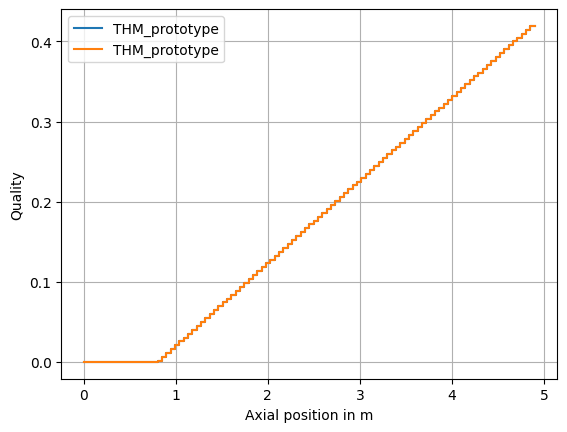

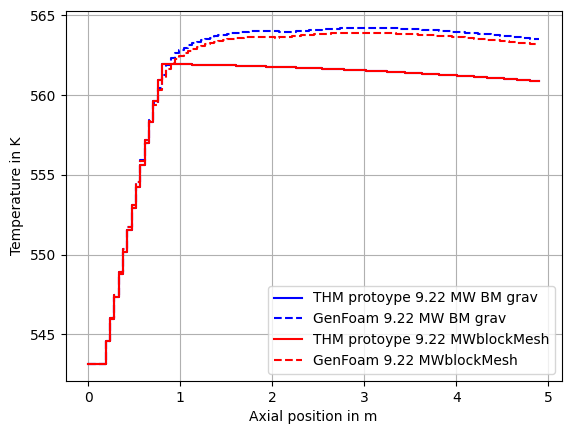

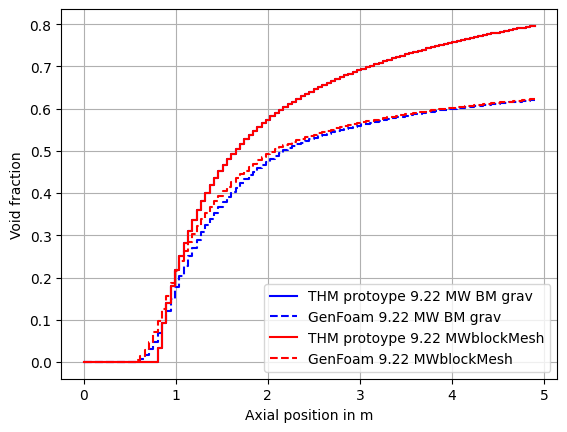

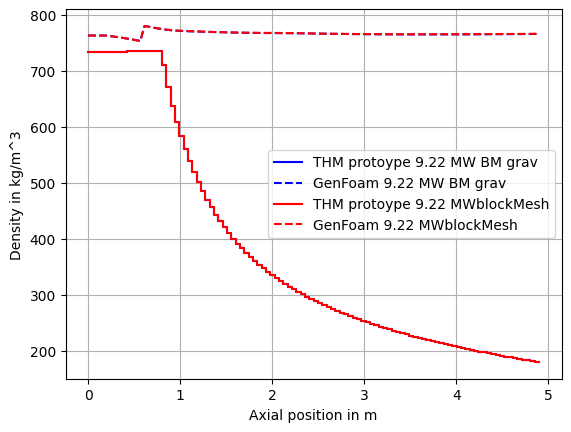

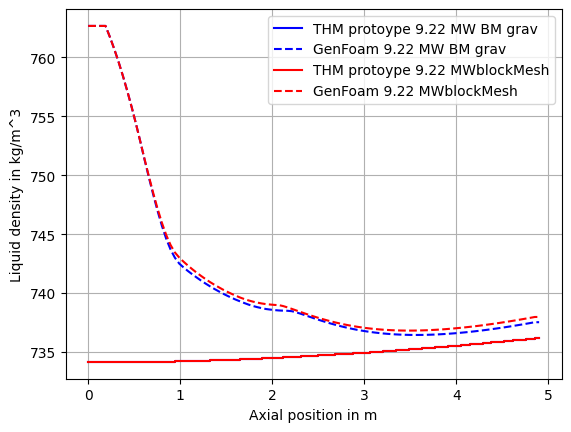

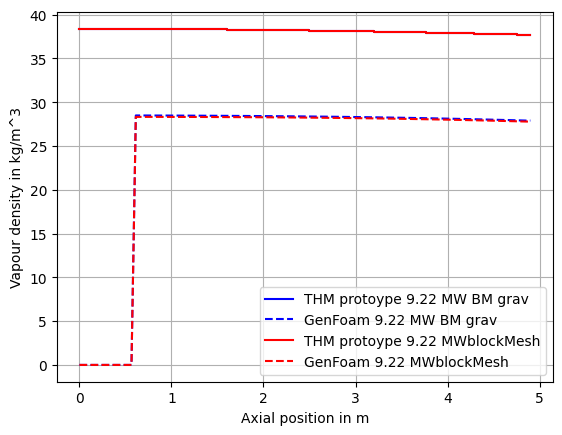

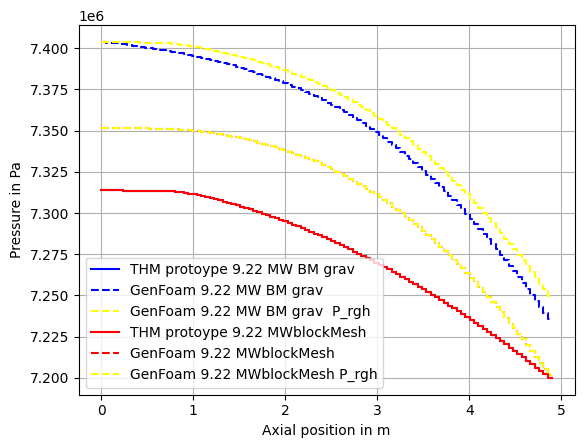

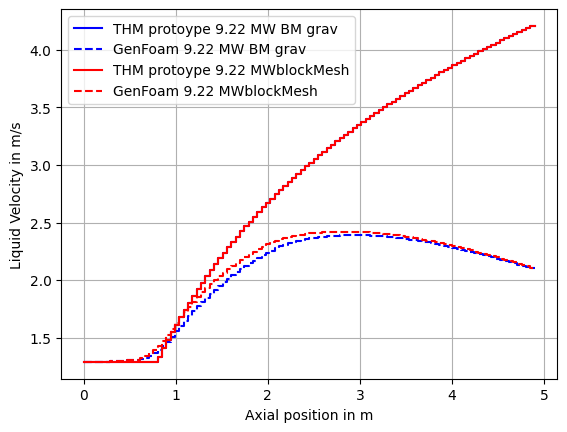

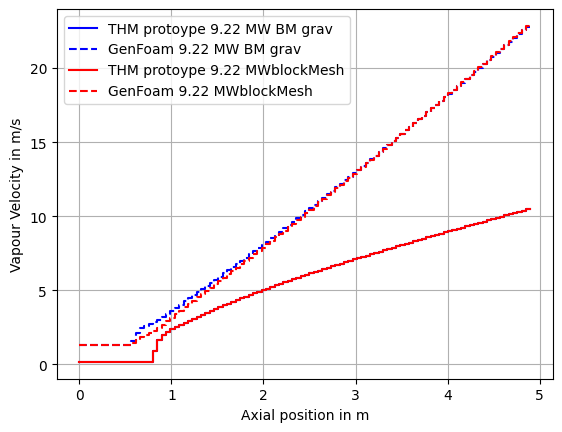

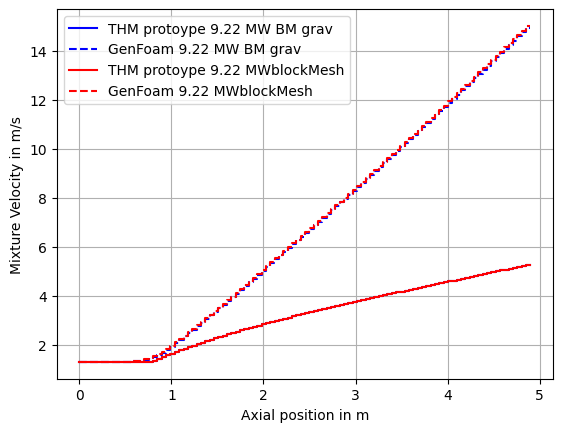

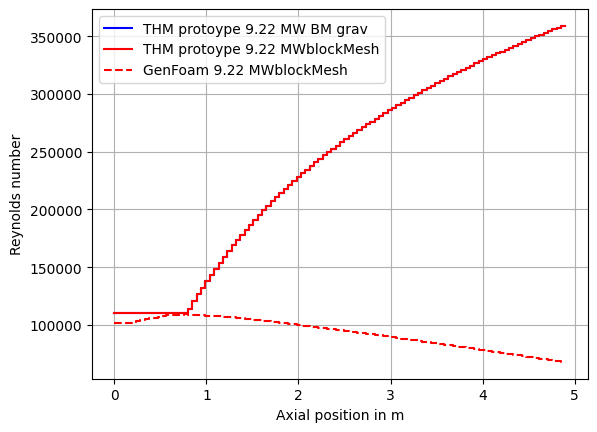

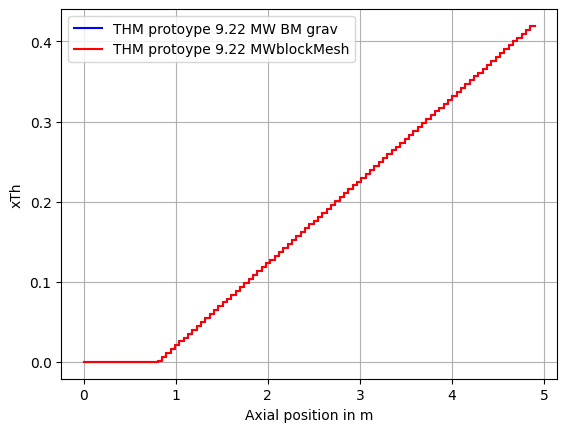

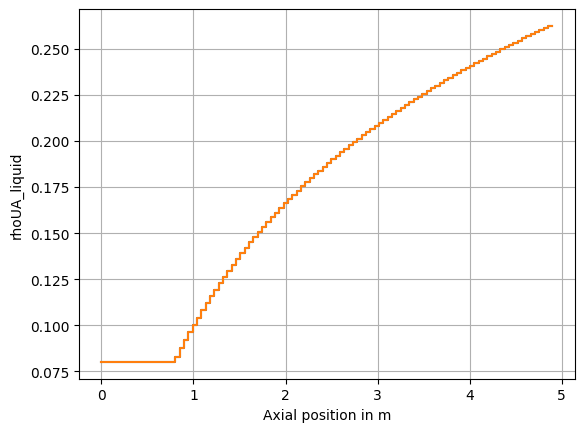

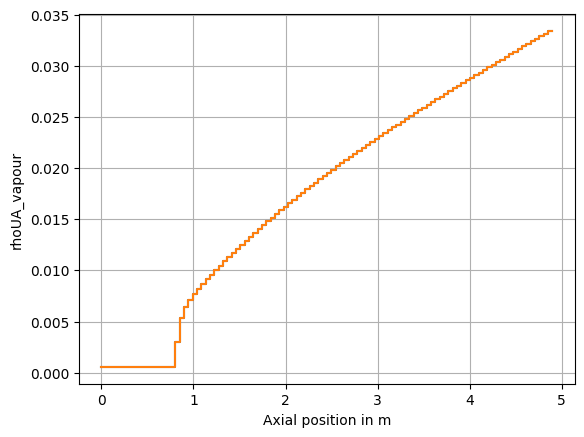

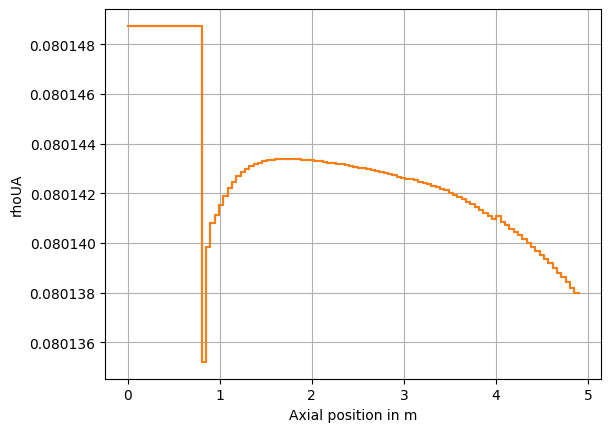

In [80]:
title1 = 400 * fuelRadius * 2 * np.pi * height #MW
title2 = 200 * fuelRadius * 2 * np.pi * height #MW
title3 = 100 * fuelRadius * 2 * np.pi * height #MW
plotter = GFPlotterComp([caseMerge[1], caseMerge[1]], [rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\these\AT10_2_blockMesh_grav', rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\these\AT10_2_blockMesh'], "AT10_2_blockMesh", [ f"{title2:.2f} MW BM grav ", f"{title2:.2f} MWblockMesh"])
plotter.plotComparison()

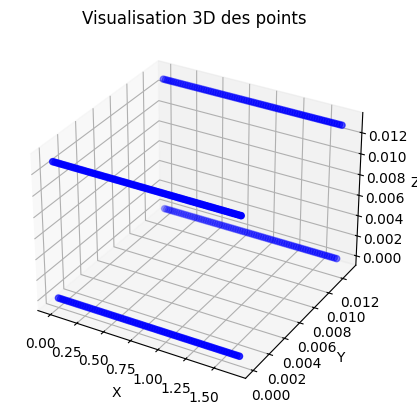

In [81]:
points = [
    (0, 0, 0), (0.02, 0, 0), (0.04, 0, 0), (0.06, 0, 0), (0.08, 0, 0), (0.1, 0, 0),
    (0, 0.01295, 0), (0.02, 0.01295, 0), (0.04, 0.01295, 0), (0.06, 0.01295, 0),
    (0.08, 0.01295, 0), (0.1, 0.01295, 0),
    (0, 0, 0.01295), (0.02, 0, 0.01295), (0.04, 0, 0.01295), (0.06, 0, 0.01295),
    (0.08, 0, 0.01295), (0.1, 0, 0.01295),
    (0, 0.01295, 0.01295), (0.02, 0.01295, 0.01295), (0.04, 0.01295, 0.01295),
    (0.06, 0.01295, 0.01295), (0.08, 0.01295, 0.01295), (0.1, 0.01295, 0.01295),
    (0.1222142857, 0, 0), (0.1444285714, 0, 0), (0.1666428571, 0, 0),
    (0.1888571429, 0, 0), (0.2110714286, 0, 0), (0.2332857143, 0, 0),
    (0.2555, 0, 0), (0.2777142857, 0, 0), (0.2999285714, 0, 0),
    (0.3221428571, 0, 0), (0.3443571429, 0, 0), (0.3665714286, 0, 0),
    (0.3887857143, 0, 0), (0.411, 0, 0), (0.4332142857, 0, 0),
    (0.4554285714, 0, 0), (0.4776428571, 0, 0), (0.4998571429, 0, 0),
    (0.5220714286, 0, 0), (0.5442857143, 0, 0), (0.5665, 0, 0),
    (0.5887142857, 0, 0), (0.6109285714, 0, 0), (0.6331428571, 0, 0),
    (0.6553571429, 0, 0), (0.6775714286, 0, 0), (0.6997857143, 0, 0),
    (0.722, 0, 0), (0.7442142857, 0, 0), (0.7664285714, 0, 0),
    (0.7886428571, 0, 0), (0.8108571429, 0, 0), (0.8330714286, 0, 0),
    (0.8552857143, 0, 0), (0.8775, 0, 0), (0.8997142857, 0, 0),
    (0.9219285714, 0, 0), (0.9441428571, 0, 0), (0.9663571429, 0, 0),
    (0.9885714286, 0, 0), (1.010785714, 0, 0), (1.033, 0, 0),
    (1.055214286, 0, 0), (1.077428571, 0, 0), (1.099642857, 0, 0),
    (1.121857143, 0, 0), (1.144071429, 0, 0), (1.166285714, 0, 0),
    (1.1885, 0, 0), (1.210714286, 0, 0), (1.232928571, 0, 0),
    (1.255142857, 0, 0), (1.277357143, 0, 0), (1.299571429, 0, 0),
    (1.321785714, 0, 0), (1.344, 0, 0), (1.366214286, 0, 0),
    (1.388428571, 0, 0), (1.410642857, 0, 0), (1.432857143, 0, 0),
    (1.455071429, 0, 0), (1.477285714, 0, 0), (1.4995, 0, 0),
    (1.521714286, 0, 0), (1.543928571, 0, 0), (1.566142857, 0, 0),
    (1.588357143, 0, 0), (1.610571429, 0, 0), (1.632785714, 0, 0),
    (1.655, 0, 0), (0.1222142857, 0.01295, 0), (0.1444285714, 0.01295, 0),
    (0.1666428571, 0.01295, 0), (0.1888571429, 0.01295, 0),
    (0.2110714286, 0.01295, 0), (0.2332857143, 0.01295, 0),
    (0.2555, 0.01295, 0), (0.2777142857, 0.01295, 0),
    (0.2999285714, 0.01295, 0), (0.3221428571, 0.01295, 0),
    (0.3443571429, 0.01295, 0), (0.3665714286, 0.01295, 0),
    (0.3887857143, 0.01295, 0), (0.411, 0.01295, 0),
    (0.4332142857, 0.01295, 0), (0.4554285714, 0.01295, 0),
    (0.4776428571, 0.01295, 0), (0.4998571429, 0.01295, 0),
    (0.5220714286, 0.01295, 0), (0.5442857143, 0.01295, 0),
    (0.5665, 0.01295, 0), (0.5887142857, 0.01295, 0),
    (0.6109285714, 0.01295, 0), (0.6331428571, 0.01295, 0),
    (0.6553571429, 0.01295, 0), (0.6775714286, 0.01295, 0),
    (0.6997857143, 0.01295, 0), (0.722, 0.01295, 0),
    (0.7442142857, 0.01295, 0), (0.7664285714, 0.01295, 0),
    (0.7886428571, 0.01295, 0), (0.8108571429, 0.01295, 0),
    (0.8330714286, 0.01295, 0), (0.8552857143, 0.01295, 0),
    (0.8775, 0.01295, 0), (0.8997142857, 0.01295, 0),
    (0.9219285714, 0.01295, 0), (0.9441428571, 0.01295, 0),
    (0.9663571429, 0.01295, 0), (0.9885714286, 0.01295, 0),
    (1.010785714, 0.01295, 0), (1.033, 0.01295, 0),
    (1.055214286, 0.01295, 0),    (1.077428571, 0.01295, 0), (1.099642857, 0.01295, 0),
    (1.121857143, 0.01295, 0), (1.144071429, 0.01295, 0),
    (1.166285714, 0.01295, 0), (1.1885, 0.01295, 0),
    (1.210714286, 0.01295, 0), (1.232928571, 0.01295, 0),
    (1.255142857, 0.01295, 0), (1.277357143, 0.01295, 0),
    (1.299571429, 0.01295, 0), (1.321785714, 0.01295, 0),
    (1.344, 0.01295, 0), (1.366214286, 0.01295, 0),
    (1.388428571, 0.01295, 0), (1.410642857, 0.01295, 0),
    (1.432857143, 0.01295, 0), (1.455071429, 0.01295, 0),
    (1.477285714, 0.01295, 0), (1.4995, 0.01295, 0),
    (1.521714286, 0.01295, 0), (1.543928571, 0.01295, 0),
    (1.566142857, 0.01295, 0), (1.588357143, 0.01295, 0),
    (1.610571429, 0.01295, 0), (1.632785714, 0.01295, 0),
    (1.655, 0.01295, 0),
    (0.1222142857, 0, 0.01295), (0.1444285714, 0, 0.01295),
    (0.1666428571, 0, 0.01295), (0.1888571429, 0, 0.01295),
    (0.2110714286, 0, 0.01295), (0.2332857143, 0, 0.01295),
    (0.2555, 0, 0.01295), (0.2777142857, 0, 0.01295),
    (0.2999285714, 0, 0.01295), (0.3221428571, 0, 0.01295),
    (0.3443571429, 0, 0.01295), (0.3665714286, 0, 0.01295),
    (0.3887857143, 0, 0.01295), (0.411, 0, 0.01295),
    (0.4332142857, 0, 0.01295), (0.4554285714, 0, 0.01295),
    (0.4776428571, 0, 0.01295), (0.4998571429, 0, 0.01295),
    (0.5220714286, 0, 0.01295), (0.5442857143, 0, 0.01295),
    (0.5665, 0, 0.01295), (0.5887142857, 0, 0.01295),
    (0.6109285714, 0, 0.01295), (0.6331428571, 0, 0.01295),
    (0.6553571429, 0, 0.01295), (0.6775714286, 0, 0.01295),
    (0.6997857143, 0, 0.01295), (0.722, 0, 0.01295),
    (0.7442142857, 0, 0.01295), (0.7664285714, 0, 0.01295),
    (0.7886428571, 0, 0.01295), (0.8108571429, 0, 0.01295),
    (0.8330714286, 0, 0.01295), (0.8552857143, 0, 0.01295),
    (0.8775, 0, 0.01295), (0.8997142857, 0, 0.01295),
    (0.9219285714, 0, 0.01295), (0.9441428571, 0, 0.01295),
    (0.9663571429, 0, 0.01295), (0.9885714286, 0, 0.01295),
    (1.010785714, 0, 0.01295), (1.033, 0, 0.01295),
    (1.055214286, 0, 0.01295), (1.077428571, 0, 0.01295),
    (1.099642857, 0, 0.01295), (1.121857143, 0, 0.01295),
    (1.144071429, 0, 0.01295), (1.166285714, 0, 0.01295),
    (1.1885, 0, 0.01295), (1.210714286, 0, 0.01295),
    (1.232928571, 0, 0.01295), (1.255142857, 0, 0.01295),
    (1.277357143, 0, 0.01295), (1.299571429, 0, 0.01295),
    (1.321785714, 0, 0.01295), (1.344, 0, 0.01295),
    (1.366214286, 0, 0.01295), (1.388428571, 0, 0.01295),
    (1.410642857, 0, 0.01295), (1.432857143, 0, 0.01295),
    (1.455071429, 0, 0.01295), (1.477285714, 0, 0.01295),
    (1.4995, 0, 0.01295), (1.521714286, 0, 0.01295),
    (1.543928571, 0, 0.01295), (1.566142857, 0, 0.01295),
    (1.588357143, 0, 0.01295), (1.610571429, 0, 0.01295),
    (1.632785714, 0, 0.01295), (1.655, 0, 0.01295),
    (0.1222142857, 0.01295, 0.01295), (0.1444285714, 0.01295, 0.01295),
    (0.1666428571, 0.01295, 0.01295), (0.1888571429, 0.01295, 0.01295),
    (0.2110714286, 0.01295, 0.01295), (0.2332857143, 0.01295, 0.01295),
    (0.2555, 0.01295, 0.01295), (0.2777142857, 0.01295, 0.01295),
    (0.2999285714, 0.01295, 0.01295), (0.3221428571, 0.01295, 0.01295),
    (0.3443571429, 0.01295, 0.01295), (0.3665714286, 0.01295, 0.01295),
    (0.3887857143, 0.01295, 0.01295), (0.411, 0.01295, 0.01295),
    (0.4332142857, 0.01295, 0.01295), (0.4554285714, 0.01295, 0.01295),
    (0.4776428571, 0.01295, 0.01295), (0.4998571429, 0.01295, 0.01295),
    (0.5220714286, 0.01295, 0.01295), (0.5442857143, 0.01295, 0.01295),
    (0.5665, 0.01295, 0.01295),     (0.5887142857, 0.01295, 0.01295), (0.6109285714, 0.01295, 0.01295),
    (0.6331428571, 0.01295, 0.01295), (0.6553571429, 0.01295, 0.01295),
    (0.6775714286, 0.01295, 0.01295), (0.6997857143, 0.01295, 0.01295),
    (0.722, 0.01295, 0.01295), (0.7442142857, 0.01295, 0.01295),
    (0.7664285714, 0.01295, 0.01295), (0.7886428571, 0.01295, 0.01295),
    (0.8108571429, 0.01295, 0.01295), (0.8330714286, 0.01295, 0.01295),
    (0.8552857143, 0.01295, 0.01295), (0.8775, 0.01295, 0.01295),
    (0.8997142857, 0.01295, 0.01295), (0.9219285714, 0.01295, 0.01295),
    (0.9441428571, 0.01295, 0.01295), (0.9663571429, 0.01295, 0.01295),
    (0.9885714286, 0.01295, 0.01295), (1.010785714, 0.01295, 0.01295),
    (1.033, 0.01295, 0.01295), (1.055214286, 0.01295, 0.01295),
    (1.077428571, 0.01295, 0.01295), (1.099642857, 0.01295, 0.01295),
    (1.121857143, 0.01295, 0.01295), (1.144071429, 0.01295, 0.01295),
    (1.166285714, 0.01295, 0.01295), (1.1885, 0.01295, 0.01295),
    (1.210714286, 0.01295, 0.01295), (1.232928571, 0.01295, 0.01295),
    (1.255142857, 0.01295, 0.01295), (1.277357143, 0.01295, 0.01295),
    (1.299571429, 0.01295, 0.01295), (1.321785714, 0.01295, 0.01295),
    (1.344, 0.01295, 0.01295), (1.366214286, 0.01295, 0.01295),
    (1.388428571, 0.01295, 0.01295), (1.410642857, 0.01295, 0.01295),
    (1.432857143, 0.01295, 0.01295), (1.455071429, 0.01295, 0.01295),
    (1.477285714, 0.01295, 0.01295), (1.4995, 0.01295, 0.01295),
    (1.521714286, 0.01295, 0.01295), (1.543928571, 0.01295, 0.01295),
    (1.566142857, 0.01295, 0.01295), (1.588357143, 0.01295, 0.01295),
    (1.610571429, 0.01295, 0.01295), (1.632785714, 0.01295, 0.01295),
    (1.655, 0.01295, 0.01295)
]
# Séparer les coordonnées x, y et z
x_coords, y_coords, z_coords = zip(*points)

# Création de la figure 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Ajouter les points dans le graphique
ax.scatter(x_coords, y_coords, z_coords, c='b', marker='o')

# Labels des axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Titre
plt.title('Visualisation 3D des points')

# Afficher le graphique
plt.show()